# 04 Unsupervised: Isolation Forest on Carrier-Airport-Month Profiles


## Goals
1. Detect unusual carrier-airport-month patterns.
2. Understand how the anomalies are structured.
3. Connect anomaly scores to the supervised high-delay target.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "Airline_Delay_Cause.csv"
FIG_DIR = ROOT / "figures"
OUT_DIR = ROOT / "outputs"
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 486
CONTAMINATION = 0.05
N_ESTIMATORS = 200

In [3]:
# Read in the data
df = pd.read_csv(DATA_PATH)
df = df[df["arr_flights"] > 0].copy()

df["delay_rate"] = df["arr_del15"] / df["arr_flights"]
df["cancel_rate"] = df["arr_cancelled"] / df["arr_flights"]
df["divert_rate"] = df["arr_diverted"] / df["arr_flights"]
df["mean_delay_mins"] = df["arr_delay"] / df["arr_flights"].clip(lower=1)

cause_cols = ["carrier_ct", "weather_ct", "nas_ct", "security_ct", "late_aircraft_ct"]
cause_total = df[cause_cols].sum(axis=1).clip(lower=1)
for col in cause_cols:
    df[f"pct_{col}"] = df[col] / cause_total

df["high_delay"] = (df["delay_rate"] > 0.20).astype(int)
print(f"Rows after filtering: {len(df):,}")
print(f"High-delay rate: {df['high_delay'].mean():.3f}")

Rows after filtering: 171,426
High-delay rate: 0.379


In [4]:
ANOMALY_FEATURES = [
    "delay_rate",
    "cancel_rate",
    "divert_rate",
    "mean_delay_mins",
    "pct_carrier_ct",
    "pct_weather_ct",
    "pct_nas_ct",
    "pct_security_ct",
    "pct_late_aircraft_ct",
    "arr_flights",
]

X = df[ANOMALY_FEATURES].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=N_ESTIMATORS,
    contamination=CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_scaled)

raw_score = iso.decision_function(X_scaled)
df["anomaly_score"] = 1 - (raw_score - raw_score.min()) / (raw_score.max() - raw_score.min())
df["is_anomaly"] = (iso.predict(X_scaled) == -1).astype(int)

anomaly_rate = df["is_anomaly"].mean()
print(f"Anomalies flagged: {df['is_anomaly'].sum():,} / {len(df):,} ({anomaly_rate:.2%})")

Anomalies flagged: 8,572 / 171,426 (5.00%)


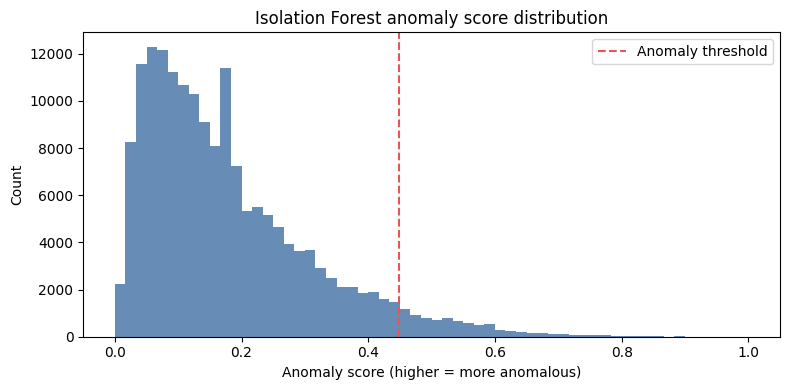

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["anomaly_score"], bins=60, color="#4C78A8", alpha=0.85)
threshold = df.loc[df["is_anomaly"] == 1, "anomaly_score"].min()
ax.axvline(threshold, color="#E45756", linestyle="--", linewidth=1.5, label="Anomaly threshold")
ax.set_title("Isolation Forest anomaly score distribution")
ax.set_xlabel("Anomaly score (higher = more anomalous)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "unsupervised_score_distribution.png", dpi=150)
plt.show()

In [6]:
top_anomalies = (
    df.sort_values("anomaly_score", ascending=False)
      .loc[:, [
          "year", "month", "carrier", "carrier_name", "airport", "airport_name",
          "delay_rate", "cancel_rate", "mean_delay_mins", "anomaly_score"
      ]]
      .head(25)
)
top_anomalies.to_csv(OUT_DIR / "top_anomalies.csv", index=False)
top_anomalies.head(10)

,year,month,carrier,carrier_name,airport,airport_name,delay_rate,cancel_rate,mean_delay_mins,anomaly_score
65157,2020,4,G4,Allegiant Air,BIL,"Billings, MT: Billings Logan International",0.071429,0.642857,3.142857,1.000000
65232,2020,4,G4,Allegiant Air,PVD,"Providence, RI: Theodore Francis Green State",0.111111,0.444444,1.666667,0.999604
70499,2020,1,G4,Allegiant Air,OGS,"Ogdensburg, NY: Ogdensburg International",0.111111,0.444444,9.000000,0.997806
65247,2020,4,G4,Allegiant Air,SCK,"Stockton, CA: Stockton Metropolitan",0.062500,0.781250,1.031250,0.996595
150844,2015,1,US,US Airways Inc.,TUS,"Tucson, AZ: Tucson International",1.000000,0.000000,86.000000,0.977803
59389,2020,8,G4,Allegiant Air,MRY,"Monterey, CA: Monterey Regional",0.400000,0.100000,52.900000,0.976454
37282,2021,10,OO,SkyWest Airlines Inc.,INL,"International Falls, MN: Falls International E...",0.207547,0.132075,85.660377,0.965805
164434,2014,1,MQ,American Eagle Airlines Inc.,ELP,"El Paso, TX: El Paso International",0.400000,0.350000,56.400000,0.955358
99121,2018,9,YV,Mesa Airlines Inc.,BDL,"Hartford, CT: Bradley International",0.272727,0.000000,45.272727,0.954986
45944,2021,5,OO,SkyWest Airlines Inc.,RIW,"Riverton/Lander, WY: Riverton Regional",0.078947,0.000000,2.605263,0.935207


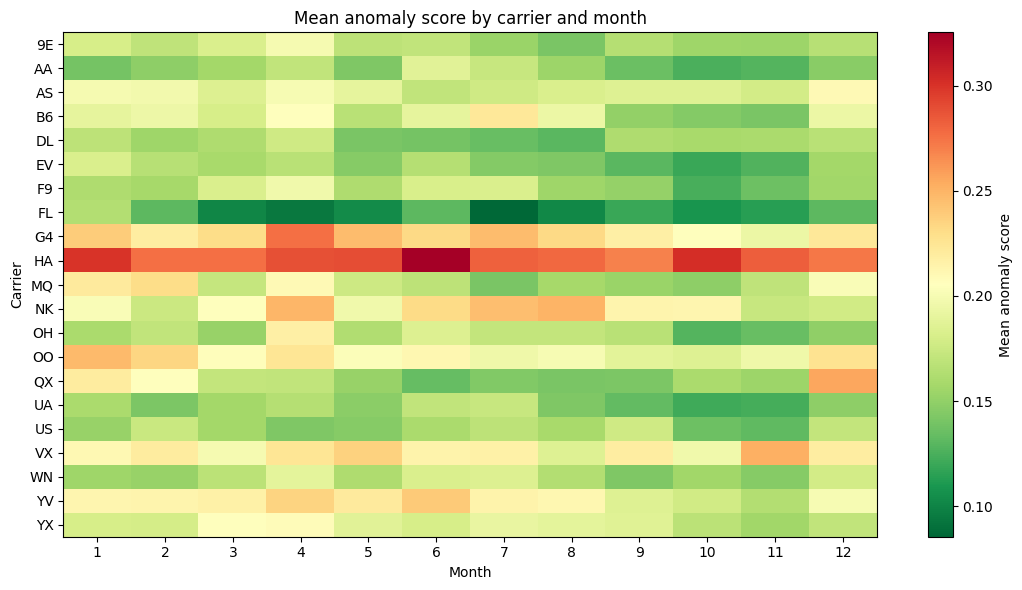

In [7]:
carrier_month = df.pivot_table(
    values="anomaly_score",
    index="carrier",
    columns="month",
    aggfunc="mean",
)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(carrier_month.values, aspect="auto", cmap="RdYlGn_r")
ax.set_xticks(range(len(carrier_month.columns)))
ax.set_xticklabels(carrier_month.columns)
ax.set_yticks(range(len(carrier_month.index)))
ax.set_yticklabels(carrier_month.index)
ax.set_title("Mean anomaly score by carrier and month")
ax.set_xlabel("Month")
ax.set_ylabel("Carrier")
plt.colorbar(im, ax=ax, label="Mean anomaly score")
plt.tight_layout()
plt.savefig(FIG_DIR / "unsupervised_carrier_month_heatmap.png", dpi=150)
plt.show()

In [8]:
df["score_quintile"] = pd.qcut(
    df["anomaly_score"],
    q=5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"],
)

connection_table = (
    df.groupby("score_quintile", observed=False)
      .agg(
          n=("high_delay", "size"),
          high_delay_rate=("high_delay", "mean"),
          mean_cancel_rate=("cancel_rate", "mean"),
          mean_delay_rate=("delay_rate", "mean"),
      )
      .reset_index()
)
connection_table.to_csv(OUT_DIR / "anomaly_supervised_connection.csv", index=False)
connection_table

,score_quintile,n,high_delay_rate,mean_cancel_rate,mean_delay_rate
0,Q1 (lowest),34286,0.331097,0.010579,0.178545
1,Q2,34285,0.396237,0.014499,0.184964
2,Q3,34285,0.367683,0.015438,0.169077
3,Q4,34285,0.385562,0.021485,0.178823
4,Q5 (highest),34285,0.416538,0.062110,0.205548


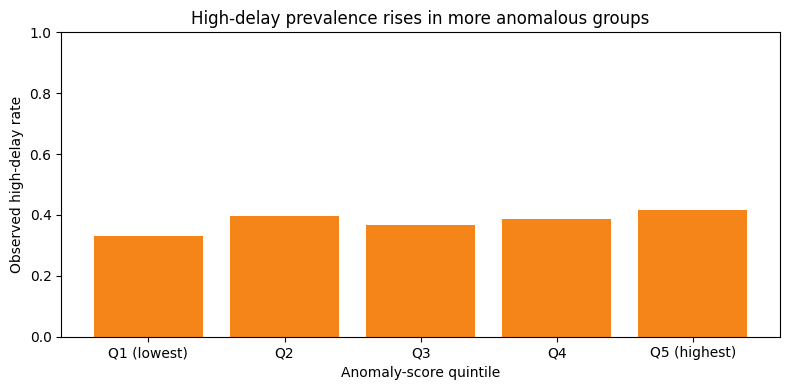

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(connection_table["score_quintile"].astype(str), connection_table["high_delay_rate"], color="#F58518")
ax.set_ylim(0, 1)
ax.set_ylabel("Observed high-delay rate")
ax.set_xlabel("Anomaly-score quintile")
ax.set_title("High-delay prevalence rises in more anomalous groups")
plt.tight_layout()
plt.savefig(FIG_DIR / "unsupervised_supervised_connection.png", dpi=150)
plt.show()

## KMeans Segmentation Layered on Isolation Forest

Isolation Forest gives each row an anomaly score. KMeans groups rows into operational patterns. Combining them helps us see **which types of operational months contain more anomalies**.

In [10]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [11]:
k_values = list(range(2, 9))
inertias = []
sil_scores = []

# Silhouette on full 171k rows is expensive (O(n^2)).
# Use a reproducible sample for fast, stable model selection.
rng = np.random.default_rng(RANDOM_STATE)
sample_n = min(20000, len(X_scaled))
sample_idx = rng.choice(len(X_scaled), size=sample_n, replace=False)
X_sel = X_scaled[sample_idx]

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_sel)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sel, labels))

best_k = k_values[int(np.argmax(sil_scores))]
print(f"Suggested k by silhouette (sample of {sample_n:,} rows): {best_k}")

/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu

Suggested k by silhouette (sample of 20,000 rows): 8


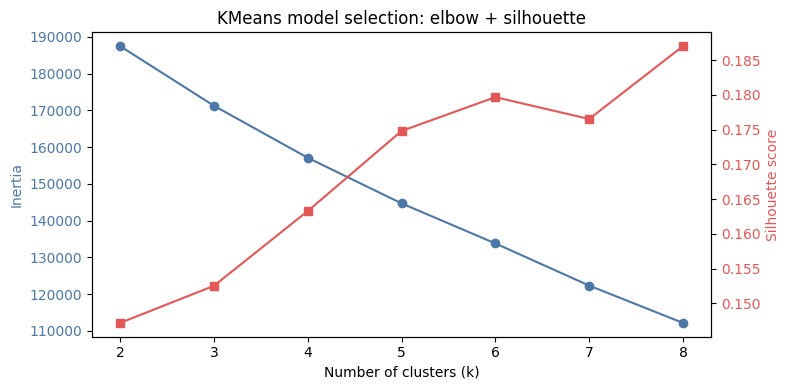

In [12]:
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(k_values, inertias, marker="o", color="#4C78A8", label="Inertia")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color="#4C78A8")
ax1.tick_params(axis="y", labelcolor="#4C78A8")

ax2 = ax1.twinx()
ax2.plot(k_values, sil_scores, marker="s", color="#E45756", label="Silhouette")
ax2.set_ylabel("Silhouette score", color="#E45756")
ax2.tick_params(axis="y", labelcolor="#E45756")

ax1.set_title("KMeans model selection: elbow + silhouette")
plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_model_selection.png", dpi=150)
plt.show()

In [13]:
# Keep k simple and interpretable. Use silhouette suggestion by default.
K = best_k
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=20)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())

/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid valu

Cluster sizes:
cluster
0    28283
1    57660
2     7262
3    28059
4    42972
5     1669
6      450
7     5071
Name: count, dtype: int64


/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/nicholasthomas/Library/Python/3.9/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


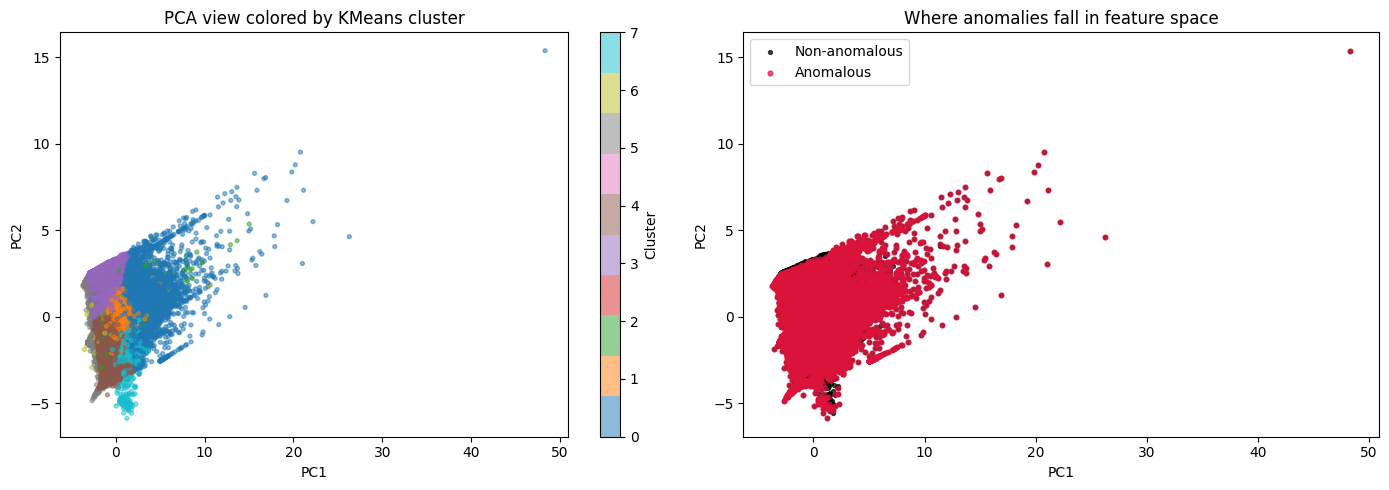

In [19]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)

plot_df = df.copy()
plot_df["pc1"] = coords[:, 0]
plot_df["pc2"] = coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: clusters
sc = axes[0].scatter(plot_df["pc1"], plot_df["pc2"], c=plot_df["cluster"], s=8, cmap="tab10", alpha=0.5)
axes[0].set_title("PCA view colored by KMeans cluster")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[0], label="Cluster")

# Right: anomalies overlaid on the same PCA map
axes[1].scatter(plot_df["pc1"], plot_df["pc2"], c="black", s=8, alpha=0.7, label="Non-anomalous")
anom = plot_df[plot_df["is_anomaly"] == 1]
axes[1].scatter(anom["pc1"], anom["pc2"], c="crimson", s=12, alpha=0.7, label="Anomalous")
axes[1].set_title("Where anomalies fall in feature space")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].legend(loc="best")

plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_pca_anomaly_overlay.png", dpi=150)
plt.show()

In [15]:
cluster_summary = (
    df.groupby("cluster", as_index=False)
      .agg(
          n=("cluster", "size"),
          anomaly_rate=("is_anomaly", "mean"),
          mean_anomaly_score=("anomaly_score", "mean"),
          high_delay_rate=("high_delay", "mean"),
          mean_delay_rate=("delay_rate", "mean"),
          mean_cancel_rate=("cancel_rate", "mean"),
      )
      .sort_values("anomaly_rate", ascending=False)
)

cluster_summary.to_csv(OUT_DIR / "kmeans_cluster_summary.csv", index=False)
cluster_summary

,cluster,n,anomaly_rate,mean_anomaly_score,high_delay_rate,mean_delay_rate,mean_cancel_rate
6,6,450,0.995556,0.598498,0.228889,0.154926,0.024883
5,5,1669,0.808268,0.540608,0.025764,0.039381,0.558682
2,2,7262,0.240980,0.356535,0.214266,0.147018,0.025047
7,7,5071,0.093670,0.341360,0.341156,0.177111,0.019080
0,0,28283,0.078881,0.221620,0.986352,0.347564,0.030158
3,3,28059,0.031612,0.188558,0.160840,0.131874,0.014741
4,4,42972,0.017290,0.164244,0.202830,0.131685,0.016109
1,1,57660,0.011949,0.113549,0.355272,0.175421,0.018627


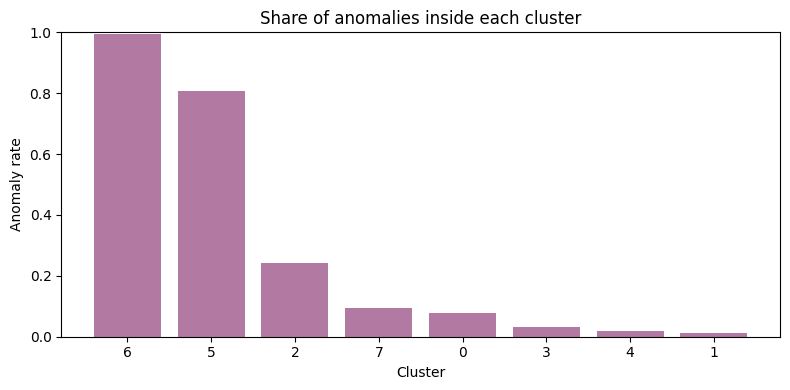

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cluster_summary["cluster"].astype(str), cluster_summary["anomaly_rate"], color="#B279A2")
ax.set_ylim(0, 1)
ax.set_xlabel("Cluster")
ax.set_ylabel("Anomaly rate")
ax.set_title("Share of anomalies inside each cluster")
plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_anomaly_rate_by_cluster.png", dpi=150)
plt.show()

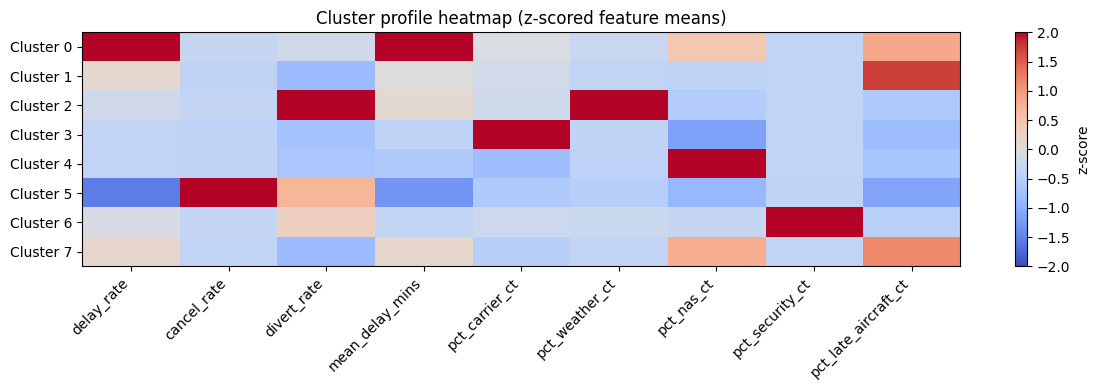

,delay_rate,cancel_rate,divert_rate,mean_delay_mins,pct_carrier_ct,pct_weather_ct,pct_nas_ct,pct_security_ct,pct_late_aircraft_ct
cluster,,,,,,,,,
0,0.347564,0.030158,0.003406,25.587312,0.345065,0.039993,0.270029,0.002085,0.342826
1,0.175421,0.018627,0.002292,10.351432,0.328093,0.030602,0.187812,0.001736,0.451755
2,0.147018,0.025047,0.007679,11.021325,0.323268,0.335344,0.172833,0.001138,0.163691
3,0.131874,0.014741,0.002496,7.667953,0.712973,0.029314,0.114160,0.001644,0.141908
4,0.131685,0.016109,0.002598,6.606142,0.243556,0.025581,0.434017,0.001945,0.155856
5,0.039381,0.558682,0.004945,2.065691,0.268205,0.016192,0.141587,0.000500,0.102570
6,0.154926,0.024883,0.004272,8.108950,0.318301,0.043056,0.195508,0.261923,0.181212
7,0.177111,0.019080,0.002298,11.533487,0.284045,0.030668,0.303593,0.002144,0.379550


In [17]:
profile_cols = [
    "delay_rate",
    "cancel_rate",
    "divert_rate",
    "mean_delay_mins",
    "pct_carrier_ct",
    "pct_weather_ct",
    "pct_nas_ct",
    "pct_security_ct",
    "pct_late_aircraft_ct",
]

profiles = df.groupby("cluster")[profile_cols].mean()
z_profiles = (profiles - profiles.mean()) / profiles.std(ddof=0)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(z_profiles.values, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(range(len(z_profiles.columns)))
ax.set_xticklabels(z_profiles.columns, rotation=45, ha="right")
ax.set_yticks(range(len(z_profiles.index)))
ax.set_yticklabels([f"Cluster {c}" for c in z_profiles.index])
ax.set_title("Cluster profile heatmap (z-scored feature means)")
plt.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()
plt.savefig(FIG_DIR / "kmeans_cluster_profiles_heatmap.png", dpi=150)
plt.show()

profiles

## Conclusion

The combined unsupervised pipeline is intuitive and complementary: Isolation Forest quantifies how unusual each carrier-airport-month is, while KMeans groups rows into recurring operational patterns. Overlaying anomaly information on clusters shows that anomalies are concentrated in specific regimes rather than spread randomly across all months. This gives two layers of insight: **unusualness** (anomaly score) and **type of behavior** (cluster label), which makes results easier to interpret and communicate. For example, Cluster 5 shows a very high cancellation profile (`mean_cancel_rate = 0.559`) and also a high anomaly concentration (`anomaly_rate = 0.808`), indicating that cancellation-shock months are one of the clearest anomaly patterns in the data.